# SPAM SMS DETECTION

## Problem Statement

Spam messages are a common issue in digital communication. The goal of this project is to build a machine learning model that can automatically classify SMS messages as Spam or Ham (Legitimate) using Natural Language Processing (NLP) techniques.

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sakth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Dataset Loading

In [32]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Data Cleaning

In [33]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Encode Labels

In [34]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [35]:
from sklearn.utils import resample

df_majority = df[df.label == 0]
df_minority = df[df.label == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df = pd.concat([df_majority, df_minority_upsampled])

## Text Preprocessing

In [36]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['message'] = df['message'].apply(preprocess_text)

## Feature Extraction (TF-IDF)

In [37]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X = tfidf.fit_transform(df['message']).toarray()
y = df['label']

## Train-Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model 1: Naive Bayes

In [39]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9632124352331606


## Model 2: Logistic Regression

In [40]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9870466321243523


## Evaluation (Confusion Matrix)

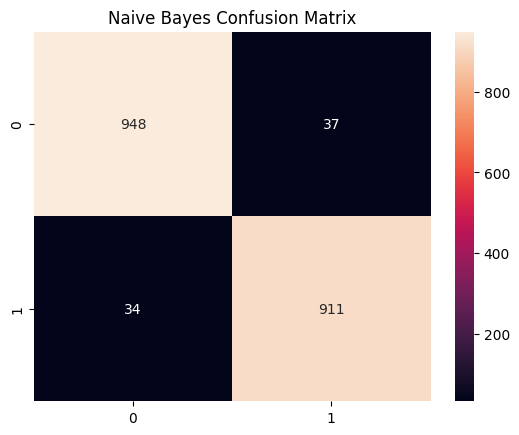

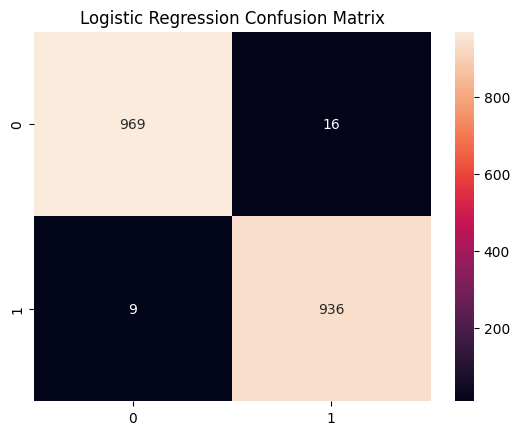

In [41]:
# Naive Bayes Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

# Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Classification Report

In [42]:
print("Naive Bayes Report:\n", classification_report(y_test, y_pred_nb))
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))

Naive Bayes Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96       985
           1       0.96      0.96      0.96       945

    accuracy                           0.96      1930
   macro avg       0.96      0.96      0.96      1930
weighted avg       0.96      0.96      0.96      1930

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       985
           1       0.98      0.99      0.99       945

    accuracy                           0.99      1930
   macro avg       0.99      0.99      0.99      1930
weighted avg       0.99      0.99      0.99      1930



## Final Prediction Function

In [43]:
def predict_sms(text):
    text = preprocess_text(text)
    vector = tfidf.transform([text]).toarray()
    
    prediction = nb_model.predict(vector)[0]
    
    if prediction == 1:
        return "Spam"
    else:
        return "Ham"

## Testing the Model

In [44]:
print(predict_sms("You won ₹10,000! Click here now!"))
print(predict_sms("Hey, are we meeting today?"))

Spam
Ham


## Conclusion

The Spam SMS Detection project was successfully implemented using Natural Language Processing (NLP) techniques and machine learning algorithms. Text data was preprocessed and transformed into numerical features using TF-IDF vectorization, enabling effective model training.

Two classification models, Naive Bayes and Logistic Regression, were applied to identify spam and legitimate messages. Both models performed well, with Naive Bayes also showing effective results in classifying SMS messages due to its suitability for text-based data.

The results demonstrate that machine learning can effectively detect spam messages and help automate filtering systems. This project highlights the practical application of NLP in solving real-world problems and lays the foundation for more advanced systems using deep learning or deployment in real-time applications.